In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

We load and take a look at the data.

In [2]:
df = pd.read_csv('/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/combined_modules_data.csv')

In [3]:
pd.set_option('display.max_columns', 60)

df.head(5)

,id_student,code_presentation,code_module,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_vle_interactions_w3,content_focus_pre_w3,collaborative_focus_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,relative_submission_date,submission_type
0,6516,2014J,AAA,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,269,606.0,0.739274,0.260726,1.812654,1.358621,6.0,2.094273,2.0,Early
1,8462,2013J,DDD,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,-137.0,119.0,261,317.0,0.886435,0.107256,1.414214,0.825578,9.0,2.357050,-4.0,Late
2,11391,2013J,AAA,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,401.0,0.862843,0.137157,1.414214,2.627691,6.0,1.479023,1.0,Early
3,23698,2014J,CCC,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass,-110.0,NaN,269,352.0,0.241477,0.068182,2.160247,0.770281,7.0,1.503976,-3.0,Late
4,24734,2014J,AAA,F,South Region,Lower Than A Level,60-70%,0-35,0,60,N,Pass,-18.0,NaN,269,87.0,0.781609,0.218391,0.894427,5.618846,5.0,1.777750,-4.0,Late


In [4]:
df.columns

Index(['id_student', 'code_presentation', 'code_module', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'module_presentation_length',
       'total_vle_interactions_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type'],
      dtype='object')

In [5]:
df["num_of_prev_attempts"].describe()

count    13709.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_of_prev_attempts, dtype: float64

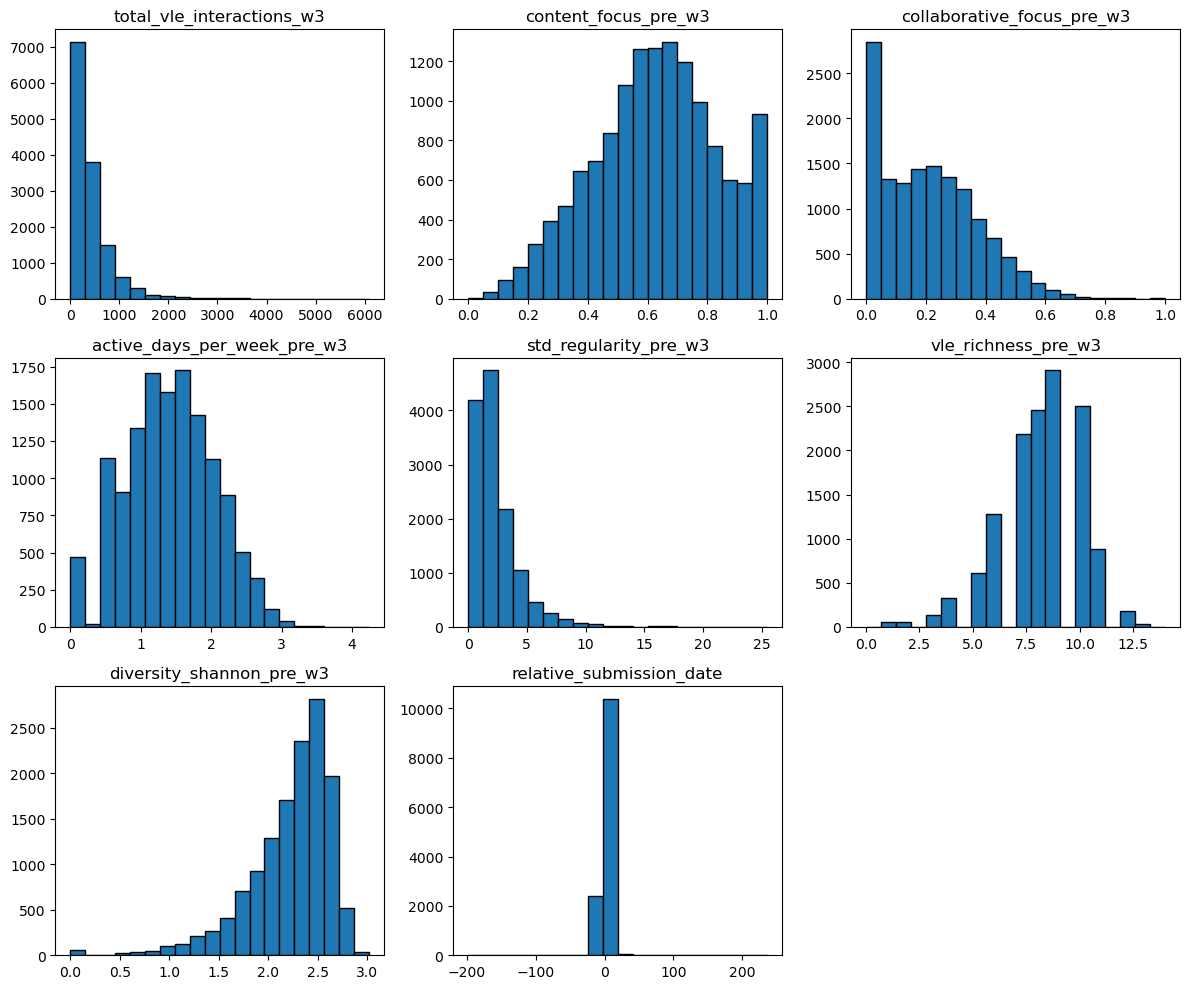

In [6]:
columns_to_display = ['total_vle_interactions_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type']

# Select only the specified columns and create histograms
df[columns_to_display].hist(bins=20, figsize=(12, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

Several of these features are skewed, but let's run baseline models before adjusting (e.g. via log)

In [7]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")


Random seed set to 42


Distribution of final_result:

Absolute counts:
final_result
Pass           6027
Withdrawn      3181
Fail           3027
Distinction    1474
Name: count, dtype: int64

Percentage distribution:
final_result
Pass           43.963819
Withdrawn      23.203735
Fail           22.080385
Distinction    10.752061
Name: proportion, dtype: float64


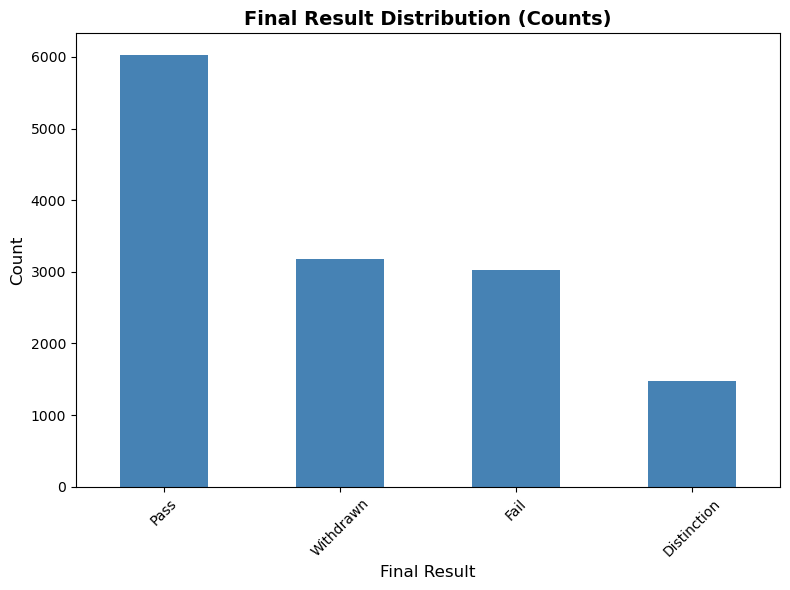


Total students: 13709
Unique categories: 4


In [8]:
# Examine the distribution of final_result

print("Distribution of final_result:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['final_result'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['final_result'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Final Result Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique categories: {df['final_result'].nunique()}")

Distribution of code_module:

Absolute counts:
code_module
FFF    5464
DDD    4205
CCC    3358
AAA     682
Name: count, dtype: int64

Percentage distribution:
code_module
FFF    39.857028
DDD    30.673280
CCC    24.494857
AAA     4.974834
Name: proportion, dtype: float64


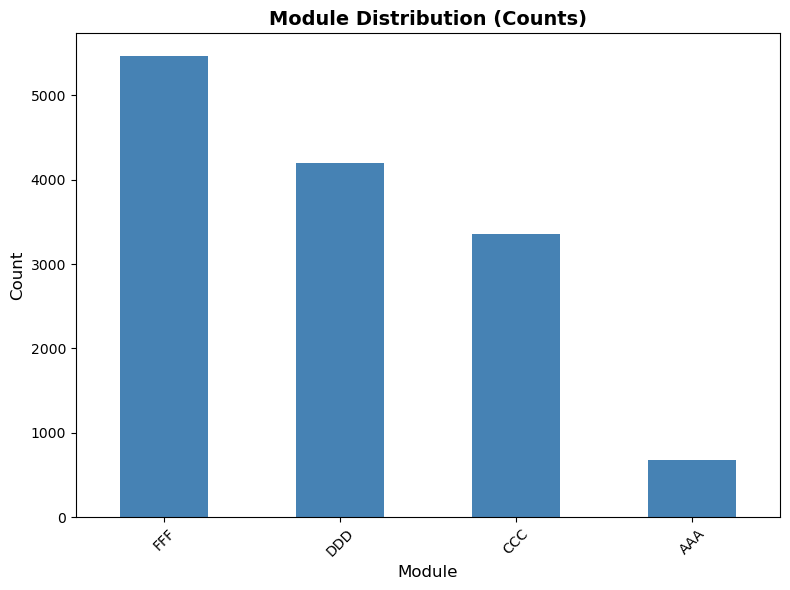


Total students: 13709
Unique modules: 4


In [9]:
# Examine the distribution of code_module

print("Distribution of code_module:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['code_module'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['code_module'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['code_module'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Module Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Module', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique modules: {df['code_module'].nunique()}")

In [19]:
from sklearn.model_selection import train_test_split

print("=" * 60)
print("CREATE TARGET VARIABLE (PREDICTING AT-RISK STUDENTS)")
print("=" * 60)

# Create binary target variable
# 1 = Fail/Withdrawn (at-risk - this is now the positive class)
# 0 = Pass/Distinction (successful)
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

print("Target variable created!")
print("\nTarget distribution:")
print(df['target'].value_counts())
print("\nTarget distribution (%):")
print(df['target'].value_counts(normalize=True) * 100)
print("\nTarget mapping:")
print("1 = Fail/Withdrawn (at-risk)")
print("0 = Pass/Distinction (successful)")

print("\n" + "=" * 60)
print("TRAIN/TEST SPLIT WITH STRATIFICATION")
print("=" * 60)

# Create a copy of the original df with the features we need
feature_columns = [
    'code_module', 
    'total_vle_interactions_w3', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    'relative_submission_date',
    'submission_type'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Drop rows with missing values
df_model_clean = df_model.dropna()
print(f"\nDataset shape after dropping missing values: {df_model_clean.shape}")

# Separate features and target BEFORE encoding
X = df_model_clean.drop('target', axis=1)
y = df_model_clean['target']

# Save code_module for stratification before encoding
code_module_for_stratification = X['code_module'].copy()

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['code_module', 'submission_type'], drop_first=True)

print(f"\nFeatures after encoding: {X_encoded.shape[1]}")
print(f"Feature columns: {list(X_encoded.columns)}")

# Create stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + code_module_for_stratification

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y,
    test_size=0.2,
    stratify=stratify_column,
    random_state=42
)

print(f"\nTrain set size: {len(X_train)} ({len(X_train)/len(X_encoded)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X_encoded)*100:.1f}%)")

# Verify stratification
print("\n" + "=" * 60)
print("STRATIFICATION VERIFICATION")
print("=" * 60)

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1=At-Risk): {y.value_counts(normalize=True).sort_index().values}")
print(f"Train (1=At-Risk):    {y_train.value_counts(normalize=True).sort_index().values}")
print(f"Test (1=At-Risk):     {y_test.value_counts(normalize=True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original: {code_module_for_stratification.value_counts(normalize=True).sort_index().values}")
print(f"Train:    {code_module_for_stratification.loc[train_indices].value_counts(normalize=True).sort_index().values}")
print(f"Test:     {code_module_for_stratification.loc[test_indices].value_counts(normalize=True).sort_index().values}")

print("\n" + "=" * 60)
print("Ready for modeling! (Predicting at-risk students)")
print("=" * 60)

CREATE TARGET VARIABLE (PREDICTING AT-RISK STUDENTS)
Target variable created!

Target distribution:
target
0    7501
1    6208
Name: count, dtype: int64

Target distribution (%):
target
0    54.71588
1    45.28412
Name: proportion, dtype: float64

Target mapping:
1 = Fail/Withdrawn (at-risk)
0 = Pass/Distinction (successful)

TRAIN/TEST SPLIT WITH STRATIFICATION

Dataset shape after dropping missing values: (12579, 11)

Features after encoding: 12
Feature columns: ['total_vle_interactions_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'relative_submission_date', 'code_module_CCC', 'code_module_DDD', 'code_module_FFF', 'submission_type_Late']

Train set size: 10063 (80.0%)
Test set size: 2516 (20.0%)

STRATIFICATION VERIFICATION

Target distribution:
------------------------------------------------------------
Original (1=At-Risk): [0.59042849 0.40957151]
Train (1=At-Ri

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

print("=" * 100)
print("MODEL COMPARISON - PREDICTING AT-RISK STUDENTS (Fail/Withdrawn)")
print("=" * 100)

# Prepare scaled data
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_scaled_mm = scaler_minmax.fit_transform(X_train)
X_test_scaled_mm = scaler_minmax.transform(X_test)

# Define all models (stratified baseline + improved models)
models = {
    'Baseline (Stratified)': {
        'model': DummyClassifier(strategy='stratified', random_state=42),
        'X_train': X_train,
        'X_test': X_test
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=5000, solver='saga', 
                                    penalty='elasticnet', l1_ratio=0.5, C=0.1, 
                                    class_weight='balanced'),
        'X_train': X_train_scaled_std,
        'X_test': X_test_scaled_std
    },
    'Logistic Regression (Multinomial)': {
        'model': LogisticRegression(random_state=42, max_iter=5000, solver='saga',
                                    penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                    multi_class='multinomial', class_weight='balanced'),
        'X_train': X_train_scaled_std,
        'X_test': X_test_scaled_std
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42, max_depth=8, 
                                       min_samples_split=30, min_samples_leaf=15,
                                       max_features='sqrt', class_weight='balanced',
                                       ccp_alpha=0.01),
        'X_train': X_train,
        'X_test': X_test
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10,
                                       min_samples_split=20, min_samples_leaf=10,
                                       class_weight='balanced'),
        'X_train': X_train,
        'X_test': X_test
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42, n_estimators=200, 
                                           learning_rate=0.05, max_depth=4,
                                           min_samples_split=20, min_samples_leaf=10,
                                           subsample=0.8, max_features='sqrt'),
        'X_train': X_train,
        'X_test': X_test
    },
    'Naïve Bayes': {
        'model': ComplementNB(alpha=0.1),
        'X_train': X_train_scaled_mm,
        'X_test': X_test_scaled_mm
    },
    'k-Nearest Neighbors': {
        'model': KNeighborsClassifier(n_neighbors=15, weights='distance', 
                                     metric='manhattan'),
        'X_train': X_train_scaled_std,
        'X_test': X_test_scaled_std
    }
}

# Function to calculate specificity
def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Function to calculate geometric mean
def calculate_geometric_mean(y_true, y_pred):
    """Calculate geometric mean of sensitivity and specificity"""
    sensitivity = recall_score(y_true, y_pred, zero_division=0)  # Recall = TPR
    specificity = calculate_specificity(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Store results
results = []

# Train and evaluate each model
for model_name, config in models.items():
    print(f"\nTraining {model_name}...")
    
    model = config['model']
    X_tr = config['X_train']
    X_te = config['X_test']
    
    # Train
    model.fit(X_tr, y_train)
    
    # Predict
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Handle baseline (may not have reliable predict_proba)
    if model_name == 'Baseline (Stratified)':
        try:
            y_train_proba = model.predict_proba(X_tr)[:, 1]
            y_test_proba = model.predict_proba(X_te)[:, 1]
            train_auc = roc_auc_score(y_train, y_train_proba)
            test_auc = roc_auc_score(y_test, y_test_proba)
        except:
            train_auc = np.nan
            test_auc = np.nan
    else:
        y_train_proba = model.predict_proba(X_tr)[:, 1]
        y_test_proba = model.predict_proba(X_te)[:, 1]
        train_auc = roc_auc_score(y_train, y_train_proba)
        test_auc = roc_auc_score(y_test, y_test_proba)
    
    # Calculate metrics for train set
    train_acc = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_specificity = calculate_specificity(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_gmean = calculate_geometric_mean(y_train, y_train_pred)
    
    # Calculate metrics for test set
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_specificity = calculate_specificity(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_gmean = calculate_geometric_mean(y_test, y_test_pred)
    
    # Store results
    results.append({
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train Precision': train_precision,
        'Test Precision': test_precision,
        'Train Recall': train_recall,
        'Test Recall': test_recall,
        'Train Specificity': train_specificity,
        'Test Specificity': test_specificity,
        'Train F1': train_f1,
        'Test F1': test_f1,
        'Train G-Mean': train_gmean,
        'Test G-Mean': test_gmean,
        'Train ROC-AUC': train_auc,
        'Test ROC-AUC': test_auc
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Display results sorted by Test G-Mean
print("\n" + "=" * 100)
print("RESULTS SUMMARY (sorted by Test G-Mean)")
print("=" * 100)
results_df_sorted = results_df.sort_values('Test G-Mean', ascending=False)
print(results_df_sorted.to_string(index=False))

# Highlight best models for each metric
print("\n" + "=" * 100)
print("BEST MODELS BY METRIC (Test Set)")
print("=" * 100)
print(f"Best Accuracy:    {results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model']:<40} ({results_df['Test Accuracy'].max():.4f})")
print(f"Best Precision:   {results_df.loc[results_df['Test Precision'].idxmax(), 'Model']:<40} ({results_df['Test Precision'].max():.4f})")
print(f"Best Recall:      {results_df.loc[results_df['Test Recall'].idxmax(), 'Model']:<40} ({results_df['Test Recall'].max():.4f})")
print(f"Best Specificity: {results_df.loc[results_df['Test Specificity'].idxmax(), 'Model']:<40} ({results_df['Test Specificity'].max():.4f})")
print(f"Best F1 Score:    {results_df.loc[results_df['Test F1'].idxmax(), 'Model']:<40} ({results_df['Test F1'].max():.4f})")
print(f"Best G-Mean:      {results_df.loc[results_df['Test G-Mean'].idxmax(), 'Model']:<40} ({results_df['Test G-Mean'].max():.4f})")
valid_auc = results_df[results_df['Test ROC-AUC'].notna()]
if len(valid_auc) > 0:
    print(f"Best ROC-AUC:     {valid_auc.loc[valid_auc['Test ROC-AUC'].idxmax(), 'Model']:<40} ({valid_auc['Test ROC-AUC'].max():.4f})")

# Check for overfitting
print("\n" + "=" * 100)
print("OVERFITTING CHECK (Train - Test Performance Gap)")
print("=" * 100)
results_df['Accuracy Gap'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
results_df['F1 Gap'] = results_df['Train F1'] - results_df['Test F1']
results_df['G-Mean Gap'] = results_df['Train G-Mean'] - results_df['Test G-Mean']
print(results_df[['Model', 'Accuracy Gap', 'F1 Gap', 'G-Mean Gap']].sort_values('G-Mean Gap', ascending=False).to_string(index=False))

# Display key test metrics in a clean format
print("\n" + "=" * 100)
print("KEY TEST SET METRICS (Predicting At-Risk Students)")
print("=" * 100)
print("Recall = % of at-risk students (Fail/Withdrawn) correctly identified")
print("Specificity = % of successful students (Pass/Distinction) correctly identified")
print("-" * 100)
key_metrics = results_df[['Model', 'Test Accuracy', 'Test Recall', 'Test Specificity', 'Test G-Mean', 'Test F1', 'Test ROC-AUC']].sort_values('Test G-Mean', ascending=False)
print(key_metrics.to_string(index=False))

# Show improvement over baseline (stratified)
print("\n" + "=" * 100)
print("IMPROVEMENT OVER BASELINE (Stratified)")
print("=" * 100)
baseline_row = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
baseline_gmean = baseline_row['Test G-Mean']
baseline_acc = baseline_row['Test Accuracy']
baseline_recall = baseline_row['Test Recall']

print(f"Baseline (Stratified): G-Mean={baseline_gmean:.4f}, Accuracy={baseline_acc:.4f}, Recall={baseline_recall:.4f}")
print("-" * 100)

for _, row in results_df.iterrows():
    if row['Model'] != 'Baseline (Stratified)':
        gmean_improvement = row['Test G-Mean'] - baseline_gmean
        acc_improvement = row['Test Accuracy'] - baseline_acc
        recall_improvement = row['Test Recall'] - baseline_recall
        print(f"{row['Model']:<40} G-Mean: {row['Test G-Mean']:.4f} ({gmean_improvement:+.4f})  |  Accuracy: {row['Test Accuracy']:.4f} ({acc_improvement:+.4f})  |  Recall: {row['Test Recall']:.4f} ({recall_improvement:+.4f})")

MODEL COMPARISON - PREDICTING AT-RISK STUDENTS (Fail/Withdrawn)

Training Baseline (Stratified)...

Training Logistic Regression...

Training Logistic Regression (Multinomial)...

Training Decision Tree...

Training Random Forest...


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



Training Gradient Boosting...

Training Naïve Bayes...

Training k-Nearest Neighbors...

RESULTS SUMMARY (sorted by Test G-Mean)
                            Model  Train Accuracy  Test Accuracy  Train Precision  Test Precision  Train Recall  Test Recall  Train Specificity  Test Specificity  Train F1  Test F1  Train G-Mean  Test G-Mean  Train ROC-AUC  Test ROC-AUC
Logistic Regression (Multinomial)        0.616317       0.614865         0.525865        0.524840      0.641349     0.635306           0.598957          0.600673  0.577894 0.574814      0.619791     0.617747       0.667780      0.659099
              Logistic Regression        0.616118       0.614467         0.525677        0.524459      0.640864     0.634336           0.598957          0.600673  0.577583 0.574188      0.619556     0.617275       0.667740      0.658970
                    Random Forest        0.727914       0.613275         0.645855        0.524702      0.743024     0.597478           0.717435          0.6242